# 05. Sistema de recomendacion final

La logica final combina tres piezas ya desarrolladas:

- embeddings semanticos multilingues con `paraphrase-multilingual-MiniLM-L12-v2` para representar publicaciones y perfiles textuales.
- transfer learning visual para representar imagenes mediante el modelo fine-tuneado del notebook 04.
- perfiles simulados con intereses declarados y likes sinteticos para evaluar recomendaciones de forma sencilla y trazable.


In [13]:
from pathlib import Path
from textwrap import shorten

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError("Falta instalar sentence-transformers. Ejecuta: %pip install -q sentence-transformers") from exc

try:
    from torchvision import models, transforms
    from torchvision.models import ResNet18_Weights
except ImportError as exc:
    raise ImportError("Este notebook requiere torchvision. Instala la libreria con: %pip install torchvision") from exc

SEED = 42
TOP_K = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = Path("data/posts.csv")
EMBEDDINGS_ARTIFACT_PATH = Path("artifacts/embeddings_posts.joblib")
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_MODEL_DIR = Path("models/modelo_embeddings")
VISION_CHECKPOINT_PATH = Path("models/vision_resnet18_head_only.pth")
IMAGES_DIR = Path("data/images")

np.random.seed(SEED)
pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Dispositivo disponible: {DEVICE}")
print(f"Artefacto de embeddings: {EMBEDDINGS_ARTIFACT_PATH}")
print(f"Modelo textual activo: {EMBEDDING_MODEL_NAME}")
print(f"Checkpoint visual: {VISION_CHECKPOINT_PATH}")


Dispositivo disponible: cuda
Artefacto de embeddings: artifacts\embeddings_posts.joblib
Modelo textual activo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Checkpoint visual: models\vision_resnet18_head_only.pth


## 1. Carga de artefactos y preparacion comun

El notebook 02 ya dejo persistidos los embeddings de publicaciones y el modelo semantico multilingue. El notebook 04 dejo persistido el estado del modelo visual fine-tuneado. Aqui solo se cargan ambos componentes para integrarlos en un flujo final de recomendacion.


In [14]:
PROMPTS_CATEGORIA = {
    "animales": "me gustan fotos y publicaciones de animales, mascotas y escenas con fauna",
    "coches": "me interesan coches, conduccion, carreteras y vehiculos en movimiento",
    "cocina": "me gusta descubrir recetas, comida, platos y momentos de cocina",
    "deporte": "me interesan entrenamientos, partidos, ejercicio y vida deportiva",
    "musica": "me gusta la musica, conciertos, canciones y ambientes musicales",
    "playa": "me atraen la playa, el mar, la arena y el ambiente costero",
    "viajes": "me interesan escapadas, destinos, paisajes y experiencias de viaje",
    "videojuegos": "me gustan los videojuegos, consolas, streaming y escenas de juego",
}

if not EMBEDDINGS_ARTIFACT_PATH.exists():
    raise FileNotFoundError(f"No se encontro el artefacto de embeddings en {EMBEDDINGS_ARTIFACT_PATH}")
if not EMBEDDING_MODEL_DIR.exists():
    raise FileNotFoundError(f"No se encontro el modelo de embeddings en {EMBEDDING_MODEL_DIR}")
if not VISION_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"No se encontro el checkpoint visual en {VISION_CHECKPOINT_PATH}")
if not IMAGES_DIR.exists():
    raise FileNotFoundError(f"No se encontro la carpeta de imagenes en {IMAGES_DIR}")

embedding_artifact = joblib.load(EMBEDDINGS_ARTIFACT_PATH)
embedding_model_name_artifact = embedding_artifact.get("embedding_model_name", EMBEDDING_MODEL_NAME)
if embedding_model_name_artifact != EMBEDDING_MODEL_NAME:
    raise ValueError(
        "El artefacto textual no fue generado con el modelo multilingue esperado. "
        f"Se encontro {embedding_model_name_artifact} y se esperaba {EMBEDDING_MODEL_NAME}. "
        "Reejecuta el notebook 02 para regenerarlo."
    )

embedding_model_dir = Path(embedding_artifact.get("embedding_model_dir", EMBEDDING_MODEL_DIR))
if not embedding_model_dir.exists():
    embedding_model_dir = EMBEDDING_MODEL_DIR
if not embedding_model_dir.exists():
    raise FileNotFoundError(f"No se encontro el modelo multilingue en {embedding_model_dir}")

modelo_embeddings = SentenceTransformer(str(embedding_model_dir), local_files_only=True)

posts_df = embedding_artifact["posts"].copy().reset_index(drop=True)
matriz_embeddings_posts = embedding_artifact["embeddings"].astype(np.float32)
posts_df["post_idx"] = np.arange(len(posts_df))
posts_df["texto_resumido"] = (
    posts_df["descripcion"].fillna("").astype(str).str.strip()
    + " "
    + posts_df["hashtags"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip().map(
    lambda texto: shorten(texto, width=100, placeholder="...")
)

print(f"Publicaciones disponibles para recomendar: {len(posts_df)}")
print(f"Modelo de embeddings cargado: {EMBEDDING_MODEL_NAME}")
print(f"Directorio local activo: {embedding_model_dir}")
print(f"Dimensiones de embeddings textuales: {matriz_embeddings_posts.shape[1]}")
display(posts_df[[col for col in ["categoria", "categoria_secundaria", "texto_resumido"] if col in posts_df.columns]].head(6))


def normalizar_vector(vector):
    norma = np.linalg.norm(vector, axis=1, keepdims=True)
    norma = np.clip(norma, 1e-12, None)
    return vector / norma


def frases_desde_intereses(categorias):
    return [PROMPTS_CATEGORIA[categoria] for categoria in categorias]


def seleccionar_likes_texto(df_posts, categorias, seed=SEED):
    likes = []
    usados = set()
    for offset, categoria in enumerate(categorias):
        subset = df_posts[df_posts["categoria"].eq(categoria)].copy()
        if subset.empty:
            continue
        muestra = subset.sample(n=1, random_state=seed + offset)
        idx = int(muestra.iloc[0]["post_idx"])
        if idx in usados:
            continue
        usados.add(idx)
        likes.append(muestra)
    if not likes:
        likes.append(df_posts.sample(n=1, random_state=seed))
    likes_df = pd.concat(likes, ignore_index=True)
    return likes_df


def construir_perfil_textual(categorias, likes_df):
    frases_intereses = frases_desde_intereses(categorias)
    embeddings_intereses = modelo_embeddings.encode(
        frases_intereses,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    embeddings_likes = matriz_embeddings_posts[likes_df["post_idx"].to_numpy()]
    perfil = np.vstack([embeddings_intereses, embeddings_likes]).mean(axis=0, keepdims=True)
    perfil = normalizar_vector(perfil)
    return perfil, frases_intereses


def recomendar_posts(perfil_textual, excluir_post_idx, top_k=TOP_K):
    scores = cosine_similarity(perfil_textual, matriz_embeddings_posts).ravel()
    ranking = posts_df.copy()
    ranking["score_similitud"] = scores
    ranking = ranking[~ranking["post_idx"].isin(set(excluir_post_idx))].copy()
    ranking = ranking.sort_values("score_similitud", ascending=False).head(top_k).copy().reset_index(drop=True)
    ranking.insert(0, "posicion", np.arange(1, len(ranking) + 1))
    ranking["score_similitud"] = ranking["score_similitud"].round(4)
    return ranking


def precision_at_k_categoria(ranking_df, columna_categoria, intereses):
    return float(ranking_df[columna_categoria].isin(set(intereses)).mean())


def resumir_vector_textual(perfil_textual, n_dimensiones=8):
    resumen = {f"dim_{i}": float(np.round(perfil_textual[0, i], 4)) for i in range(min(n_dimensiones, perfil_textual.shape[1]))}
    resumen["norma_l2"] = float(np.round(np.linalg.norm(perfil_textual), 4))
    resumen["dimensiones_totales"] = int(perfil_textual.shape[1])
    return pd.DataFrame([resumen])


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6173.80it/s]


Publicaciones disponibles para recomendar: 10873
Modelo de embeddings cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Directorio local activo: models\modelo_embeddings
Dimensiones de embeddings textuales: 384


,categoria,categoria_secundaria,texto_resumido
0,deporte,cocina,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario...
1,viajes,NaN,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸 #gymbro #escapada #top
2,viajes,NaN,vuelo temprano con cafe dudoso en Londres con camara #Travel
3,playa,NaN,"vibe de hoy: baño rapido antes de comer, que locura jajaja #Random#Verano"
4,playa,NaN,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja #sol"
5,musica,NaN,ebuFrEHS2JpDzfOvz1dOOdTXglHilC2e #Aesthetic


## 2. Representacion visual reutilizando el notebook 04

Para las imagenes se reutiliza el modelo fine-tuneado del notebook 04. En lugar de entrenar otra arquitectura, se usa la salida probabilistica del clasificador visual como representacion ligera y alineada con las categorias del TFM. De este modo, los perfiles visuales y las recomendaciones de imagen permanecen en el mismo espacio semantico de categorias.


In [15]:
checkpoint_visual = torch.load(VISION_CHECKPOINT_PATH, map_location="cpu")
class_names = checkpoint_visual["class_names"]
weights = ResNet18_Weights.DEFAULT

IMAGENET_MEAN = checkpoint_visual.get("normalization", {}).get("mean", [0.485, 0.456, 0.406])
IMAGENET_STD = checkpoint_visual.get("normalization", {}).get("std", [0.229, 0.224, 0.225])
IMAGE_SIZE = checkpoint_visual.get("image_size", 224)
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".JPEG", ".PNG"}


def crear_modelo_visual(class_names):
    modelo = models.resnet18(weights=weights)
    for param in modelo.parameters():
        param.requires_grad = False
    modelo.fc = nn.Linear(modelo.fc.in_features, len(class_names))
    return modelo.to(DEVICE)


eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

modelo_visual = crear_modelo_visual(class_names)
modelo_visual.load_state_dict(checkpoint_visual["model_state_dict"])
modelo_visual.eval()


class ImagePathDataset(Dataset):
    def __init__(self, rutas, transform):
        self.rutas = [Path(ruta) for ruta in rutas]
        self.transform = transform

    def __len__(self):
        return len(self.rutas)

    def __getitem__(self, idx):
        ruta = self.rutas[idx]
        imagen = Image.open(ruta).convert("RGB")
        tensor = self.transform(imagen)
        return tensor, str(ruta)


def construir_catalogo_imagenes(images_dir):
    filas = []
    for split in ["train", "test"]:
        split_dir = images_dir / split
        for categoria_dir in sorted(split_dir.iterdir()):
            if not categoria_dir.is_dir():
                continue
            for ruta in sorted(categoria_dir.iterdir()):
                if ruta.suffix.lower() not in {ext.lower() for ext in VALID_EXTENSIONS}:
                    continue
                filas.append(
                    {
                        "ruta": str(ruta),
                        "archivo": ruta.name,
                        "split": split,
                        "categoria_real": categoria_dir.name,
                    }
                )
    catalogo = pd.DataFrame(filas)
    catalogo["image_idx"] = np.arange(len(catalogo))
    return catalogo


@torch.no_grad()
def predecir_probabilidades_catalogo(modelo, rutas, batch_size=32):
    dataset = ImagePathDataset(rutas, eval_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    embeddings = []
    predicciones = []
    confianzas = []
    for tensores, _ in loader:
        tensores = tensores.to(DEVICE)
        logits = modelo(tensores)
        probs = torch.softmax(logits, dim=1).cpu().numpy().astype(np.float32)
        probs = normalizar_vector(probs)
        embeddings.append(probs)
        pred_idx = probs.argmax(axis=1)
        predicciones.extend([class_names[idx] for idx in pred_idx])
        confianzas.extend(probs.max(axis=1).tolist())
    return np.vstack(embeddings), predicciones, confianzas


catalogo_imagenes_df = construir_catalogo_imagenes(IMAGES_DIR)
matriz_embeddings_imagenes, categorias_predichas, confianzas_predichas = predecir_probabilidades_catalogo(
    modelo_visual,
    catalogo_imagenes_df["ruta"].tolist(),
)
catalogo_imagenes_df["embedding_visual"] = [fila for fila in matriz_embeddings_imagenes]
catalogo_imagenes_df["categoria_predicha"] = categorias_predichas
catalogo_imagenes_df["confianza_predicha"] = np.round(confianzas_predichas, 4)

catalogo_train_df = catalogo_imagenes_df[catalogo_imagenes_df["split"].eq("train")].copy().reset_index(drop=True)
catalogo_test_df = catalogo_imagenes_df[catalogo_imagenes_df["split"].eq("test")].copy().reset_index(drop=True)
matriz_test_imagenes = np.vstack(catalogo_test_df["embedding_visual"].to_numpy())

print(f"Imagenes de train disponibles para likes simulados: {len(catalogo_train_df)}")
print(f"Imagenes de test disponibles para recomendar: {len(catalogo_test_df)}")
print(f"Espacio visual reutilizado: {matriz_test_imagenes.shape[1]} categorias")
display(catalogo_imagenes_df.head(6))


def seleccionar_likes_imagenes(df_imagenes, categorias, seed=SEED):
    likes = []
    usados = set()
    for offset, categoria in enumerate(categorias):
        subset = df_imagenes[df_imagenes["categoria_real"].eq(categoria)].copy()
        if subset.empty:
            continue
        muestra = subset.sample(n=1, random_state=seed + offset)
        idx = int(muestra.iloc[0]["image_idx"])
        if idx in usados:
            continue
        usados.add(idx)
        likes.append(muestra)
    if not likes:
        likes.append(df_imagenes.sample(n=1, random_state=seed))
    likes_df = pd.concat(likes, ignore_index=True)
    return likes_df


def vector_intereses_visual(categorias):
    vector = np.array([[1.0 if categoria in categorias else 0.0 for categoria in class_names]], dtype=np.float32)
    return normalizar_vector(vector)


def construir_perfil_visual(categorias, likes_df):
    intereses_vec = vector_intereses_visual(categorias)
    likes_vec = np.vstack(likes_df["embedding_visual"].to_numpy())
    perfil = np.vstack([intereses_vec, likes_vec]).mean(axis=0, keepdims=True)
    perfil = normalizar_vector(perfil)
    return perfil


def recomendar_imagenes(perfil_visual, top_k=TOP_K):
    scores = cosine_similarity(perfil_visual, matriz_test_imagenes).ravel()
    ranking = catalogo_test_df.copy()
    ranking["score_similitud"] = scores
    ranking = ranking.sort_values("score_similitud", ascending=False).head(top_k).copy().reset_index(drop=True)
    ranking.insert(0, "posicion", np.arange(1, len(ranking) + 1))
    ranking["score_similitud"] = ranking["score_similitud"].round(4)
    return ranking


def resumir_perfil_visual(perfil_visual):
    return pd.DataFrame([
        {categoria: float(np.round(valor, 4)) for categoria, valor in zip(class_names, perfil_visual.ravel())}
    ])


def mostrar_galeria_imagenes(ranking_df, titulo):
    if ranking_df.empty:
        print("No hay imagenes para mostrar en la galeria.")
        return
    fig, axes = plt.subplots(1, len(ranking_df), figsize=(3.2 * len(ranking_df), 3.8))
    if len(ranking_df) == 1:
        axes = [axes]
    for ax, (_, fila) in zip(axes, ranking_df.iterrows()):
        imagen = Image.open(fila["ruta"]).convert("RGB")
        ax.imshow(imagen)
        ax.set_title(
            "{}. {}\nscore={}\nreal={}".format(
                fila["posicion"],
                fila["categoria_predicha"],
                fila["score_similitud"],
                fila["categoria_real"],
            ),
            fontsize=9,
        )
        ax.axis("off")
    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()


C:\Users\rafae\AppData\Local\Temp\ipykernel_23380\922205953.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_visual = torch.load(VISION_CHECKPOINT_PATH, map_lo

Imagenes de train disponibles para likes simulados: 677
Imagenes de test disponibles para recomendar: 146
Espacio visual reutilizado: 8 categorias


,ruta,archivo,split,categoria_real,image_idx,embedding_visual,categoria_predicha,confianza_predicha
0,data\images\train\animales\Barking-Mad-Dog-Sitting-car-10-1-e1569492372594.jpg,Barking-Mad-Dog-Sitting-car-10-1-e1569492372594.jpg,train,animales,0,"[0.9998349, 0.0072394754, 0.000911259, 0.0035598653, 0.00071986497, 0.0136040775, 0.00878037, 0.0012544726]",animales,0.9998
1,data\images\train\animales\cat-on-tower.jpg,cat-on-tower.jpg,train,animales,1,"[0.9986449, 0.000146289, 0.0039699767, 0.0061581517, 0.04350238, 0.0022570437, 0.02667562, 0.0067510693]",animales,0.9986
2,data\images\train\animales\cat10.jpg,cat10.jpg,train,animales,2,"[0.99915445, 0.002602976, 0.04032947, 0.0010264686, 0.0011734138, 0.0031852631, 0.003189046, 0.0058610686]",animales,0.9992
3,data\images\train\animales\cat11.jpg,cat11.jpg,train,animales,3,"[0.99870086, 0.008571669, 0.033335235, 0.029425994, 0.009699848, 0.017623065, 0.0017187195, 0.011757465]",animales,0.9987
4,data\images\train\animales\cat12.jpg,cat12.jpg,train,animales,4,"[0.99980456, 0.005333409, 0.011361924, 0.0011678302, 0.006903642, 0.00310366, 0.0046631265, 0.01236985]",animales,0.9998
5,data\images\train\animales\cat13.jpg,cat13.jpg,train,animales,5,"[0.99993366, 0.0016316845, 0.010770915, 0.0010279384, 0.002349192, 0.0015923686, 0.001180427, 0.0018632564]",animales,0.9999


## 3. Usuarios simulados

Cada perfil combina intereses declarados y likes sinteticos. Esto permite evaluar un caso de uso muy simple pero expresivo: un usuario no llega vacio al sistema, sino con algunas preferencias iniciales y unas pocas interacciones previas.


In [16]:
USUARIOS_SIMULADOS = [
    {"usuario": "Usuario 1", "intereses": ["playa", "animales", "viajes"]},
    {"usuario": "Usuario 2", "intereses": ["videojuegos", "musica"]},
    {"usuario": "Usuario 3", "intereses": ["coches", "viajes"]},
    {"usuario": "Usuario 4", "intereses": ["cocina", "playa"]},
    {"usuario": "Usuario 5", "intereses": ["deporte", "animales"]},
]

usuarios_df = pd.DataFrame(USUARIOS_SIMULADOS)
usuarios_df["descripcion_perfil"] = usuarios_df["intereses"].apply(lambda intereses: " | ".join(intereses))
display(usuarios_df)


def preparar_tabla_likes_texto(likes_df):
    columnas = [columna for columna in ["categoria", "categoria_secundaria", "texto_resumido"] if columna in likes_df.columns]
    return likes_df[columnas].copy().reset_index(drop=True)


def preparar_tabla_recomendaciones_texto(ranking_df):
    columnas = [columna for columna in ["posicion", "categoria", "score_similitud", "texto_resumido"] if columna in ranking_df.columns]
    return ranking_df[columnas].copy().reset_index(drop=True)


def preparar_tabla_likes_imagenes(likes_df):
    return likes_df[["archivo", "categoria_real", "categoria_predicha", "confianza_predicha"]].copy().reset_index(drop=True)


def preparar_tabla_recomendaciones_imagenes(ranking_df):
    return ranking_df[["posicion", "archivo", "categoria_real", "categoria_predicha", "confianza_predicha", "score_similitud"]].copy().reset_index(drop=True)


,usuario,intereses,descripcion_perfil
0,Usuario 1,"[playa, animales, viajes]",playa | animales | viajes
1,Usuario 2,"[videojuegos, musica]",videojuegos | musica
2,Usuario 3,"[coches, viajes]",coches | viajes
3,Usuario 4,"[cocina, playa]",cocina | playa
4,Usuario 5,"[deporte, animales]",deporte | animales


## 4. Recomendacion final para cada usuario

En cada iteracion se muestran cuatro piezas:

1. intereses declarados.
2. likes simulados de texto e imagen.
3. perfil generado en el espacio textual y en el espacio visual.
4. ranking Top-5 de publicaciones y de imagenes con una evaluacion `Precision@5` sencilla.


Usuario 1
Intereses declarados: ['playa', 'animales', 'viajes']
Frases usadas para el perfil textual:
- me atraen la playa, el mar, la arena y el ambiente costero
- me gustan fotos y publicaciones de animales, mascotas y escenas con fauna
- me interesan escapadas, destinos, paisajes y experiencias de viaje
Likes simulados de texto:


,categoria,categoria_secundaria,texto_resumido
0,playa,viajes,nadie me preparo para paseo por calas de Paris despues de perder el bus del hotel muy de hoy...
1,animales,playa,me desperte pensando en esto: atardecer cerca del mar con paseo largo y cero prisa. No encaja...
2,viajes,NaN,plan improvisado: escapada express con maleta pequeña en Cadiz con camara; en plan tranquilo y...


Embedding de perfil textual generado:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,norma_l2,dimensiones_totales
0,0.081,-0.0188,0.0334,0.0482,0.0912,-0.0214,0.0141,-0.0015,1.0,384


Top-5 publicaciones recomendadas:


...

,archivo,categoria_real,categoria_predicha,confianza_predicha
0,gsun_0e4ecdc71756b8f75724b1cf562b4b95.jpg,playa,playa,0.9978
1,horse17.jpg,animales,animales,0.9999
2,viajes_18.jpg,viajes,playa,0.7579


Perfil visual generado:


,animales,coches,cocina,deporte,musica,playa,viajes,videojuegos
0,0.5093,0.0076,0.0003,0.0032,0.0106,0.7532,0.416,0.0056


Top-5 imagenes recomendadas:


,posicion,archivo,categoria_real,categoria_predicha,confianza_predicha,score_similitud
0,1,elephant359.jpg,animales,playa,0.7842,0.9168
1,2,joyful-dog-running-along-sandy-600nw-2393515545.jpg,animales,playa,0.8329,0.9139
2,3,gsun_0172e63006665122f2dc33c735b70b23.jpg,playa,playa,0.8124,0.8553
3,4,gsun_02acf3f2f873f92ff06cc7ba2ae2798c.jpg,playa,playa,0.7674,0.8457
4,5,00000074_(3).jpg,viajes,playa,0.7172,0.8336


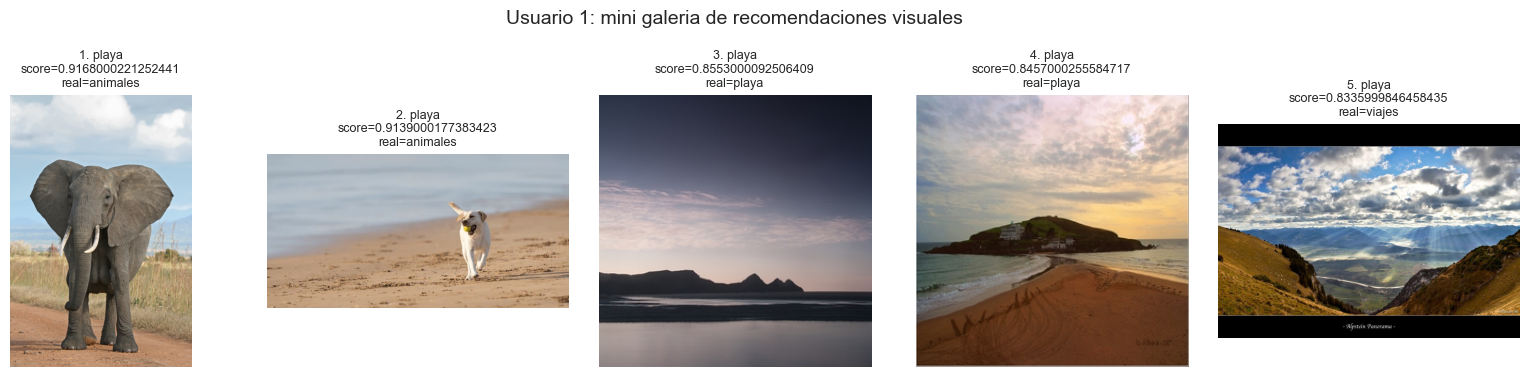

Precision@5 imagenes: 1.000
Usuario 2
Intereses declarados: ['videojuegos', 'musica']
Frases usadas para el perfil textual:
- me gustan los videojuegos, consolas, streaming y escenas de juego
- me gusta la musica, conciertos, canciones y ambientes musicales
Likes simulados de texto:


,categoria,categoria_secundaria,texto_resumido
0,videojuegos,NaN,vibe de hoy: GTA no puedo mas ⚽ #Gamer #StudyTok
1,musica,videojuegos,#FIFA #Vibes #Spotify #Musica


Embedding de perfil textual generado:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,norma_l2,dimensiones_totales
0,0.0339,-0.0789,0.0484,0.0028,-0.0257,0.0635,0.0554,-0.0051,1.0,384


Top-5 publicaciones recomendadas:


...

,archivo,categoria_real,categoria_predicha,confianza_predicha
0,videojuegos_75.png,videojuegos,videojuegos,0.9999
1,musica_41.jpg,musica,musica,1.0000


Perfil visual generado:


,animales,coches,cocina,deporte,musica,playa,viajes,videojuegos
0,0.0032,0.0006,0.0017,0.0007,0.7071,0.0019,0.0046,0.707


Top-5 imagenes recomendadas:


,posicion,archivo,categoria_real,categoria_predicha,confianza_predicha,score_similitud
0,1,simon-weisser-phS37wg8cQg-unsplash.jpg,musica,musica,0.8786,0.9419
1,2,4420b729-c6d7-496a-8030-6be37906872b.jpg,animales,videojuegos,0.9265,0.8282
2,3,visualsofdana-Dm4Uc78Vs50-unsplash.jpg,musica,musica,0.6185,0.7539
3,4,image_974.png,videojuegos,videojuegos,0.9989,0.7245
4,5,deep-sonowal-X-oKPBGdBL8-unsplash.jpg,musica,musica,0.9868,0.7176


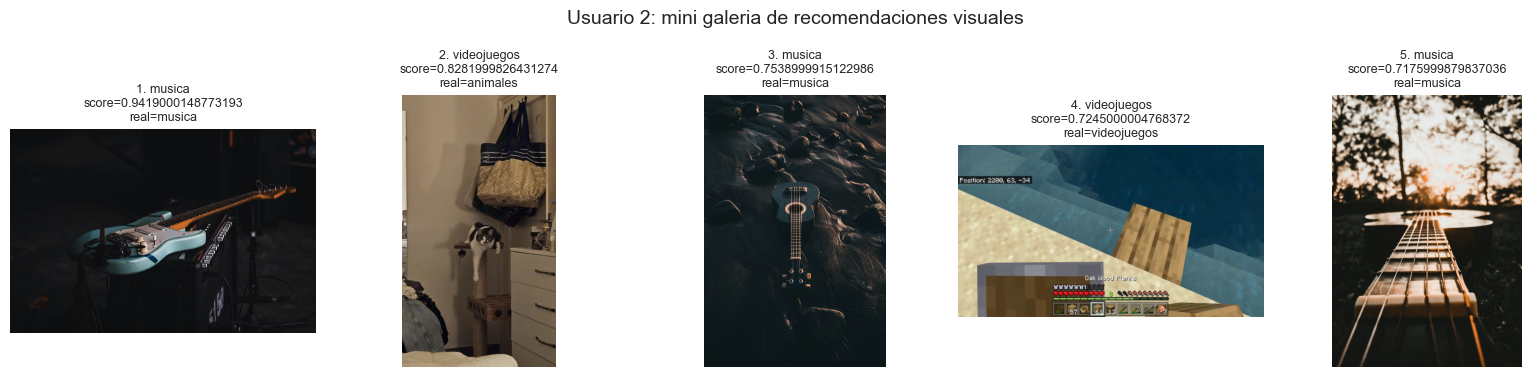

Precision@5 imagenes: 0.800
Usuario 3
Intereses declarados: ['coches', 'viajes']
Frases usadas para el perfil textual:
- me interesan coches, conduccion, carreteras y vehiculos en movimiento
- me interesan escapadas, destinos, paisajes y experiencias de viaje
Likes simulados de texto:


,categoria,categoria_secundaria,texto_resumido
0,coches,viajes,"si esto no es felicidad entonces nada ruta larga con el Ferrari, maleta atras y cero ganas de..."
1,viajes,NaN,"hotel sencillo pero bien ubicado, no pido mas #Travel #Destino"


Embedding de perfil textual generado:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,norma_l2,dimensiones_totales
0,0.1242,0.0084,-0.0187,0.045,0.0424,0.0298,0.0301,0.0157,1.0,384


Top-5 publicaciones recomendadas:


...

,archivo,categoria_real,categoria_predicha,confianza_predicha
0,79.jpg,coches,coches,0.9762
1,viajes_16.jpg,viajes,playa,0.8512


Perfil visual generado:


,animales,coches,cocina,deporte,musica,playa,viajes,videojuegos
0,0.0378,0.7097,0.0065,0.0138,0.0079,0.366,0.6002,0.0172


Top-5 imagenes recomendadas:


,posicion,archivo,categoria_real,categoria_predicha,confianza_predicha,score_similitud
0,1,engin-akyurt-vehpa8SzmFg-unsplash.jpg,coches,coches,0.8235,0.8020
1,2,zoshua-colah-l4M_E0JSbn8-unsplash.jpg,coches,coches,0.9923,0.7662
2,3,119.jpg,coches,coches,0.9990,0.7283
3,4,1bc69c7934.jpg,viajes,viajes,0.9208,0.7267
4,5,image_399.png,videojuegos,coches,0.9911,0.7245


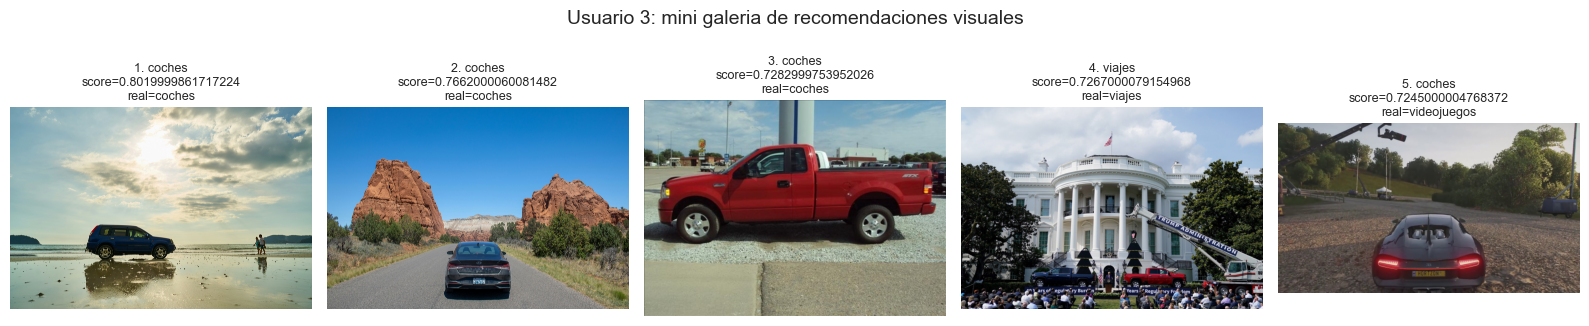

Precision@5 imagenes: 0.800
Usuario 4
Intereses declarados: ['cocina', 'playa']
Frases usadas para el perfil textual:
- me gusta descubrir recetas, comida, platos y momentos de cocina
- me atraen la playa, el mar, la arena y el ambiente costero
Likes simulados de texto:


,categoria,categoria_secundaria,texto_resumido
0,cocina,NaN,"receta vista en TikTok y cero medidas cerca de Tenerife. despues de una semana eterna, Mercadona..."
1,playa,NaN,"calas pequeñas sin cobertura. Entre perro, no se #Calas#GymBro"


Embedding de perfil textual generado:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,norma_l2,dimensiones_totales
0,0.0185,0.0074,0.0587,0.0688,0.0084,-0.0233,0.0549,0.0072,1.0,384


Top-5 publicaciones recomendadas:


...

,archivo,categoria_real,categoria_predicha,confianza_predicha
0,3-ingredient-tomato-soup.jpg,cocina,cocina,1.0000
1,gsun_0cfb0d4124e0df4e90feffd5423c8fa3.jpg,playa,playa,0.9989


Perfil visual generado:


,animales,coches,cocina,deporte,musica,playa,viajes,videojuegos
0,0.0063,0.0003,0.7099,0.0007,0.0006,0.704,0.0175,0.002


Top-5 imagenes recomendadas:


,posicion,archivo,categoria_real,categoria_predicha,confianza_predicha,score_similitud
0,1,gsun_029ce1b4f92b1b94050bfda9b33b79bb.jpg,playa,playa,0.9864,0.7615
1,2,gsun_08299d9fb0fe112a1e8be4c207b2633f.jpg,playa,playa,0.9969,0.7280
2,3,tarragon-spiked-lady-grey-iced-tea-239285.jpg,cocina,cocina,0.9819,0.7235
3,4,tart-cranberry-onion-relish-236418.jpg,cocina,cocina,0.9910,0.7140
4,5,tarragon-chicken-fricassee-237587.jpg,cocina,cocina,1.0000,0.7119


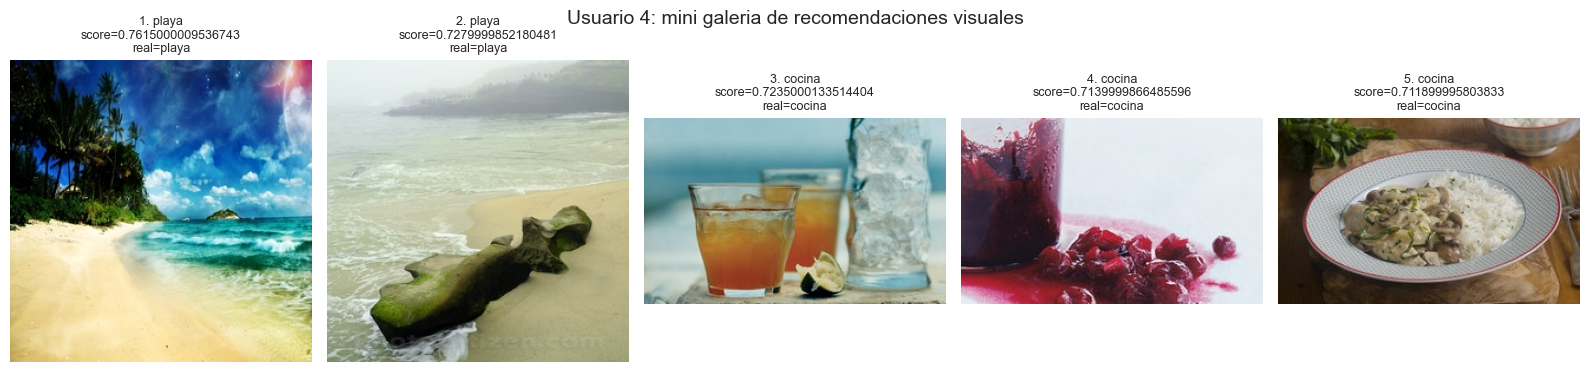

Precision@5 imagenes: 1.000
Usuario 5
Intereses declarados: ['deporte', 'animales']
Frases usadas para el perfil textual:
- me interesan entrenamientos, partidos, ejercicio y vida deportiva
- me gustan fotos y publicaciones de animales, mascotas y escenas con fauna
Likes simulados de texto:


,categoria,categoria_secundaria,texto_resumido
0,deporte,NaN,mryWg5k586RSg4XGa81Vyd4bm
1,animales,playa,me desperte pensando en esto: atardecer cerca del mar con paseo largo y cero prisa. No encaja...


Embedding de perfil textual generado:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,norma_l2,dimensiones_totales
0,0.027,-0.0088,0.0276,0.0594,0.015,-0.0325,0.0041,-0.012,1.0,384


Top-5 publicaciones recomendadas:


...

,archivo,categoria_real,categoria_predicha,confianza_predicha
0,deporte_76.jpg,deporte,deporte,0.9987
1,horse17.jpg,animales,animales,0.9999


Perfil visual generado:


,animales,coches,cocina,deporte,musica,playa,viajes,videojuegos
0,0.7078,0.0015,0.0038,0.706,0.0119,0.0032,0.0023,0.0201


Top-5 imagenes recomendadas:


,posicion,archivo,categoria_real,categoria_predicha,confianza_predicha,score_similitud
0,1,dog-7956828_1280.jpg,animales,animales,0.9229,0.7728
1,2,00000483.jpg,deporte,deporte,0.9962,0.7405
2,3,horse952.jpg,animales,animales,0.9856,0.7172
3,4,dog1.jpg,animales,animales,0.9998,0.7141
4,5,horse951.jpg,animales,animales,0.9996,0.7134


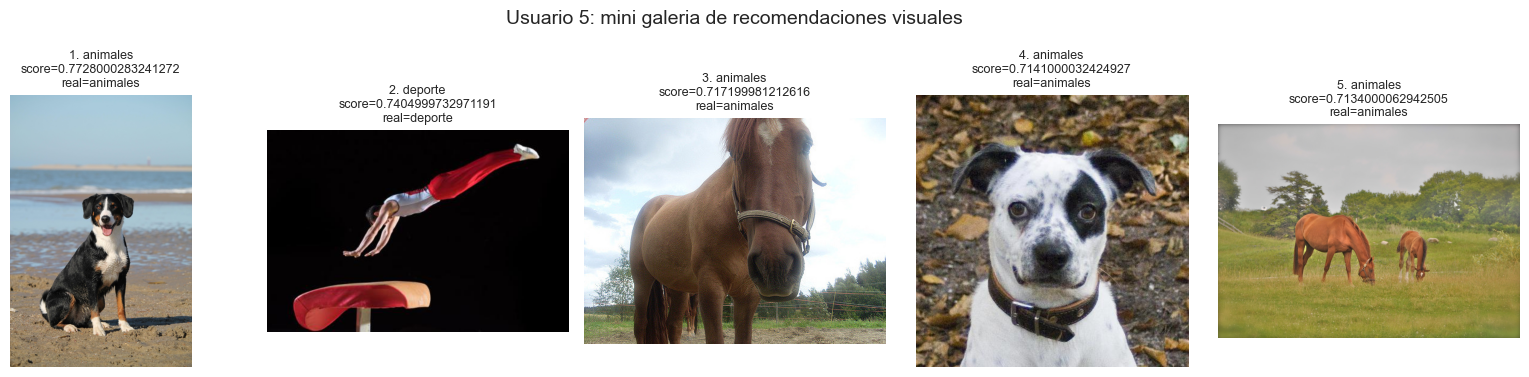

Precision@5 imagenes: 1.000


In [17]:
resultados_usuarios = []
metricas_usuarios = []

for perfil in USUARIOS_SIMULADOS:
    usuario = perfil["usuario"]
    intereses = perfil["intereses"]
    intereses_set = set(intereses)

    likes_texto_df = seleccionar_likes_texto(posts_df, intereses)
    perfil_textual, frases_intereses = construir_perfil_textual(intereses, likes_texto_df)
    ranking_texto_df = recomendar_posts(perfil_textual, likes_texto_df["post_idx"].tolist(), top_k=TOP_K)
    precision_texto = precision_at_k_categoria(ranking_texto_df, "categoria", intereses_set)

    likes_imagenes_df = seleccionar_likes_imagenes(catalogo_train_df, intereses)
    perfil_visual = construir_perfil_visual(intereses, likes_imagenes_df)
    ranking_imagenes_df = recomendar_imagenes(perfil_visual, top_k=TOP_K)
    precision_imagenes = precision_at_k_categoria(ranking_imagenes_df, "categoria_real", intereses_set)

    print("=" * 120)
    print(usuario)
    print("Intereses declarados:", intereses)
    print("Frases usadas para el perfil textual:")
    for frase in frases_intereses:
        print("-", frase)

    print("Likes simulados de texto:")
    display(preparar_tabla_likes_texto(likes_texto_df))
    print("Embedding de perfil textual generado:")
    display(resumir_vector_textual(perfil_textual))
    print("Top-5 publicaciones recomendadas:")
    display(preparar_tabla_recomendaciones_texto(ranking_texto_df))
    print(f"Precision@5 texto: {precision_texto:.3f}")

    print("Likes simulados de imagen:")
    display(preparar_tabla_likes_imagenes(likes_imagenes_df))
    print("Perfil visual generado:")
    display(resumir_perfil_visual(perfil_visual))
    print("Top-5 imagenes recomendadas:")
    display(preparar_tabla_recomendaciones_imagenes(ranking_imagenes_df))
    mostrar_galeria_imagenes(ranking_imagenes_df, f"{usuario}: mini galeria de recomendaciones visuales")
    print(f"Precision@5 imagenes: {precision_imagenes:.3f}")

    resultados_usuarios.append(
        {
            "usuario": usuario,
            "intereses": intereses,
            "likes_texto_df": likes_texto_df,
            "ranking_texto_df": ranking_texto_df,
            "likes_imagenes_df": likes_imagenes_df,
            "ranking_imagenes_df": ranking_imagenes_df,
        }
    )
    metricas_usuarios.append(
        {
            "usuario": usuario,
            "intereses": " | ".join(intereses),
            "precision_at_5_texto": round(precision_texto, 4),
            "precision_at_5_imagenes": round(precision_imagenes, 4),
            "categorias_texto_top5": " | ".join(ranking_texto_df["categoria"].tolist()),
            "categorias_imagenes_top5": " | ".join(ranking_imagenes_df["categoria_real"].tolist()),
        }
    )


## 5. Evaluacion agregada y lectura final del sistema

La evaluacion no busca competir con un benchmark externo. Solo comprueba si el contenido recomendado se alinea con los intereses declarados de cada usuario simulado. Para ello, una recomendacion se considera relevante cuando su categoria pertenece al conjunto de intereses del perfil.


,usuario,intereses,precision_at_5_texto,precision_at_5_imagenes,categorias_texto_top5,categorias_imagenes_top5,precision_media
0,Usuario 1,playa | animales | viajes,1.0,1.0,viajes | viajes | viajes | viajes | playa,animales | animales | playa | playa | viajes,1.0
1,Usuario 2,videojuegos | musica,1.0,0.8,videojuegos | videojuegos | videojuegos | videojuegos | videojuegos,musica | animales | musica | videojuegos | musica,0.9
2,Usuario 3,coches | viajes,0.8,0.8,viajes | viajes | viajes | coches | deporte,coches | coches | coches | viajes | videojuegos,0.8
3,Usuario 4,cocina | playa,0.6,1.0,playa | playa | coches | animales | playa,playa | playa | cocina | cocina | cocina,0.8
4,Usuario 5,deporte | animales,0.6,1.0,animales | animales | animales | playa | playa,animales | deporte | animales | animales | animales,0.8


,modalidad,precision_at_5_media
0,Texto,0.800
1,Imagenes,0.920


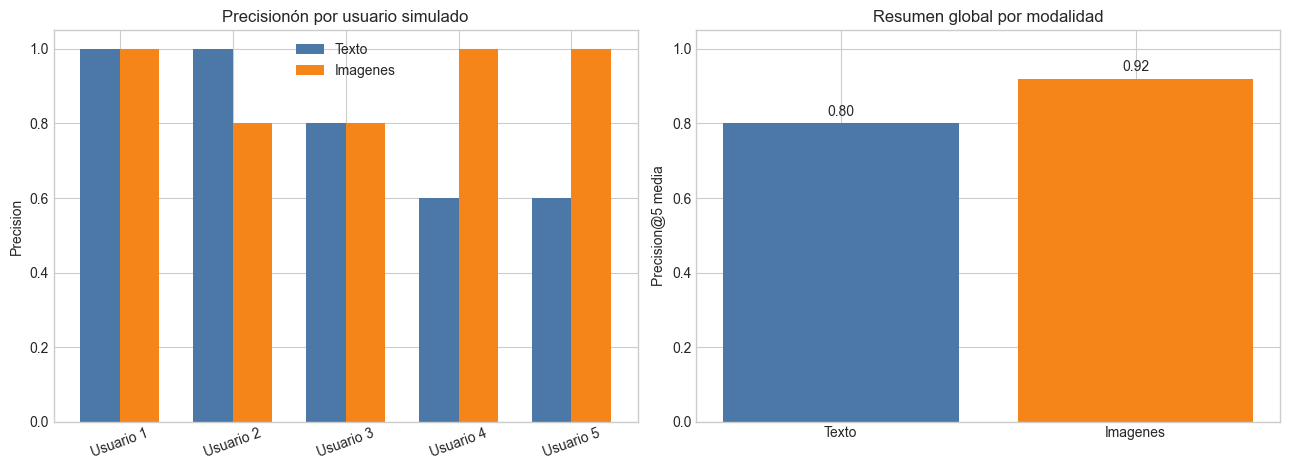

Resumen de categorias recomendadas en texto:


,usuario,categorias_texto_top5
0,Usuario 1,viajes | viajes | viajes | viajes | playa
1,Usuario 2,videojuegos | videojuegos | videojuegos | videojuegos | videojuegos
2,Usuario 3,viajes | viajes | viajes | coches | deporte
3,Usuario 4,playa | playa | coches | animales | playa
4,Usuario 5,animales | animales | animales | playa | playa


Resumen de categorias recomendadas en imagenes:


,usuario,categorias_imagenes_top5
0,Usuario 1,animales | animales | playa | playa | viajes
1,Usuario 2,musica | animales | musica | videojuegos | musica
2,Usuario 3,coches | coches | coches | viajes | videojuegos
3,Usuario 4,playa | playa | cocina | cocina | cocina
4,Usuario 5,animales | deporte | animales | animales | animales


In [18]:
metricas_df = pd.DataFrame(metricas_usuarios)
metricas_df["precision_media"] = metricas_df[["precision_at_5_texto", "precision_at_5_imagenes"]].mean(axis=1).round(4)

display(metricas_df)

metricas_globales_df = pd.DataFrame(
    [
        {
            "modalidad": "Texto",
            "precision_at_5_media": metricas_df["precision_at_5_texto"].mean(),
        },
        {
            "modalidad": "Imagenes",
            "precision_at_5_media": metricas_df["precision_at_5_imagenes"].mean(),
        },
    ]
)
display(metricas_globales_df.style.format({"precision_at_5_media": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

x = np.arange(len(metricas_df))
width = 0.35
axes[0].bar(x - width / 2, metricas_df["precision_at_5_texto"], width=width, label="Texto", color="#4C78A8")
axes[0].bar(x + width / 2, metricas_df["precision_at_5_imagenes"], width=width, label="Imagenes", color="#F58518")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_df["usuario"], rotation=20)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Precision")
axes[0].set_title("Precisionón por usuario simulado")
axes[0].legend()

axes[1].bar(metricas_globales_df["modalidad"], metricas_globales_df["precision_at_5_media"], color=["#4C78A8", "#F58518"])
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Precision@5 media")
axes[1].set_title("Resumen global por modalidad")
for idx, valor in enumerate(metricas_globales_df["precision_at_5_media"]):
    axes[1].text(idx, valor + 0.02, f"{valor:.2f}", ha="center")

plt.tight_layout()
plt.show()

ranking_textual_resumen_df = metricas_df[["usuario", "categorias_texto_top5"]].copy()
ranking_visual_resumen_df = metricas_df[["usuario", "categorias_imagenes_top5"]].copy()
print("Resumen de categorias recomendadas en texto:")
display(ranking_textual_resumen_df)
print("Resumen de categorias recomendadas en imagenes:")
display(ranking_visual_resumen_df)


## 6. Conclusiones finales

Este notebook cierra el TFM porque integra, sin entrenar nada nuevo, las piezas ya construidas:

1. **Que aporto TF-IDF.** Fue el baseline supervisado del proyecto. Permitio convertir texto en una primera solucion interpretable, rapida y facil de explicar. Tambien sirvio para entender que las consultas directas se resuelven bien cuando el vocabulario es muy evidente.
2. **Que aportaron los embeddings.** Permitieron representar publicaciones y perfiles de usuario en un espacio semantico mas flexible. En el cierre del proyecto ese papel recae explicitamente en `paraphrase-multilingual-MiniLM-L12-v2`, que encaja mejor con consultas en espanol y con intereses que mezclan varias categorias.
3. **Que aporto el transfer learning visual.** El modelo preentrenado aporto conocimiento visual general y el ajuste de la ultima capa lo adapto al dominio concreto del TFM. Esa pieza hace posible recomendar imagenes con una representacion ligera pero alineada con las categorias del proyecto.
4. **Como funciona el sistema final.** A partir de intereses declarados y likes simulados, el sistema construye perfiles textuales y visuales, recupera contenido similar y evalua su alineacion con `Precision@5`. La demostracion muestra, por tanto, un flujo coherente de extremo a extremo: clasificacion textual, recomendacion semantica, extension visual y sistema final de recomendacion para usuarios simulados.
